# Comparision of a traditional least-squares fit and a neural network

- True signal: Two overlapping Breit-Wigner resonances

- Traditional model 1: One Breit-Wigner (incorrect model)

- Traditional model 2: Two Breit-Wigner (correct model)

- Neural network: Regression without assuming a functional form

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import tensorflow as tf

Generating data

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

def true_signal(E):
    return ( 1.0/((E-4.0)**2+0.3**2)+ 0.6/((E-5.2)**2+0.25**2))


E_data = np.linspace(2, 8, 60)

# creating noisy data

sigma_data = true_signal(E_data) + np.random.normal(0, 0.1, size=E_data.shape)

E_smooth = np.linspace(2, 8, 500)  # dense grid, only used for plotting curves

Scipy curve fit with single breit-wigner (wrong guess of functional form)

In [8]:
def single_breit_wigner(E, A, E0, Gamma):
    return A/((E-E0)**2 + (Gamma/2)**2)
 
popt, pcov = curve_fit(single_breit_wigner, E_data, sigma_data,
    p0=[1.0, 5.0, 0.5], maxfev=10000)

A_fit, E0_fit, Gamma_fit = popt
perr = np.sqrt(np.diag(pcov))

scipy_single_pred_at_data = single_breit_wigner(E_data, *popt)
scipy_single_pred_smooth = single_breit_wigner(E_smooth, *popt)

single_chi2 = np.sum((sigma_data-scipy_single_pred_at_data)**2)/len(E_data)

print("=== scipy single-resonance fit ===")
print(f"A     = {A_fit:.3f} +/- {perr[0]:.3f}")
print(f"E0    = {E0_fit:.3f} +/- {perr[1]:.3f}")
print(f"Gamma = {Gamma_fit:.3f} +/- {perr[2]:.3f}")
print(f"per point chi square = {single_chi2:.4f}")

=== scipy single-resonance fit ===
A     = 6.946 +/- 1.611
E0    = 4.358 +/- 0.093
Gamma = 1.909 +/- 0.278
per point chi square = 3.8525


Scipy fit with double breit-wigner (correct guess of functional form)

In [9]:
def double_bw(E, A1, E1, G1, A2, E2, G2):
    return ( A1/((E-E1)**2+(G1/2)**2) + A2/((E-E2)**2+(G2/2)**2) )

# Fit the double Breit-Wigner model
popt_double, pcov_double = curve_fit(double_bw, E_data, sigma_data, 
                                     p0=[1.0, 4.0, 0.6, 0.7, 5.1, 0.45], maxfev=20000)

A1_fit, E1_fit, G1_fit, A2_fit, E2_fit, G2_fit = popt_double

perr_double = np.sqrt(np.diag(pcov_double))

scipy_double_pred_at_data = double_bw(E_data, *popt_double)
scipy_double_pred_smooth = double_bw(E_smooth, *popt_double)


double_chi2 = np.sum((sigma_data - scipy_double_pred_at_data)**2)/len(E_data)

print("=== SciPy double-resonance fit ===")
print(f"A1 = {A1_fit:.3f} ± {perr_double[0]:.3f}")
print(f"E1 = {E1_fit:.3f} ± {perr_double[1]:.3f}")
print(f"G1 = {G1_fit:.3f} ± {perr_double[2]:.3f}")

print(f"A2 = {A2_fit:.3f} ± {perr_double[3]:.3f}")
print(f"E2 = {E2_fit:.3f} ± {perr_double[4]:.3f}")
print(f"G2 = {G2_fit:.3f} ± {perr_double[5]:.3f}")

print(f"per point chi squared = {double_chi2:.4f}")

=== SciPy double-resonance fit ===
A1 = 0.977 ± 0.013
E1 = 4.002 ± 0.002
G1 = 0.592 ± 0.005
A2 = 0.584 ± 0.010
E2 = 5.199 ± 0.002
G2 = 0.491 ± 0.005
per point chi squared = 0.0068


DNN approach

Two things matter for getting a smooth, well-behaved curve out of a small network:

- Normalize the input. Feeding E data points directly into a network initialized for order 1 inputs slows convergence and tends to leave visible kinks in the fitted curve after a fixed number of epochs
- Use a smooth activation (tanh here) rather than ReLU. A ReLU network is exactly piecewise-linear, so unless you use very many units it will visibly look like a sequence of straight segments instead of a smooth peak

In [10]:
# Normalise input 

E_mean, E_std = E_data.mean(), E_data.std()
E_data_norm = (E_data - E_mean) / E_std
E_smooth_norm = (E_smooth - E_mean) / E_std
 
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(1),
])
 
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3), loss="mse")
 
history = model.fit(E_data_norm.reshape(-1, 1), sigma_data, epochs=2000, verbose=0)
 
dnn_pred_at_data = model.predict(E_data_norm.reshape(-1, 1), verbose=0).flatten()
dnn_pred_smooth = model.predict(E_smooth_norm.reshape(-1, 1), verbose=0).flatten()
 
dnn_chi2 = np.sum((sigma_data - dnn_pred_at_data) ** 2)/len(E_data)

print("=== DNN fit ===")
print(f"final training loss (MSE) = {history.history['loss'][-1]:.5f}")
print(f"per point chi squared  = {dnn_chi2:.4f}")

=== DNN fit ===
final training loss (MSE) = 0.00302
per point chi squared  = 0.0029


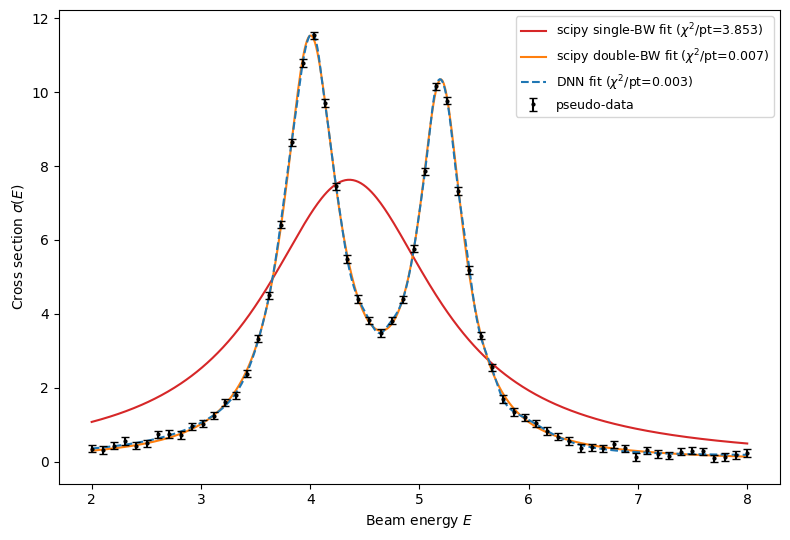

In [18]:

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.errorbar(E_data, sigma_data, yerr=0.1, fmt="o", color="black", ms=2, label="pseudo-data", capsize=3, zorder=5)
ax.plot(E_smooth, scipy_single_pred_smooth, color="tab:red", lw=1.5,label=f"scipy single-BW fit ($\\chi^2$/pt={single_chi2:.3f})")
ax.plot(E_smooth, scipy_double_pred_smooth, color="tab:orange",label=f"scipy double-BW fit ($\\chi^2$/pt={double_chi2:.3f})")
ax.plot(E_smooth, dnn_pred_smooth, '--', color="tab:blue", lw=1.5,label=f"DNN fit ($\\chi^2$/pt={dnn_chi2:.3f})")

ax.set_xlabel("Beam energy $E$")
ax.set_ylabel(r"Cross section $\sigma(E)$")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()

# Results

- As expected, when the functional form is guessed incorrectly, traditional curve fit performs poorly
- The DNN performs slightly better than the traditional fit when functional form is guessed corrcetly, at the cost of not being able to know a functional form at all
- The DNN, if trained properly, will be able to extrapolate without necessarily having the knowledge of the functional form